### CNN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
#load the data
from tensorflow.keras.datasets import fashion_mnist

# load the data
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
len(train_images)

60000

In [5]:
# define the classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [6]:
def render_train_image(index):
    plt.figure(figsize=(2, 2))
    plt.imshow(train_images[index])
    label_index = train_labels[index]
    print(f"label for {index}th image = {label_index} with class = {class_names[label_index]}")

In [7]:
def render_test_image(index):
    plt.figure(figsize=(2, 2))
    plt.imshow(test_images[index])
    label_index = test_labels[index]
    print(f"label for {index}th image = {label_index} with class = {class_names[label_index]}")
    

label for 0th image = 9 with class = Ankle boot


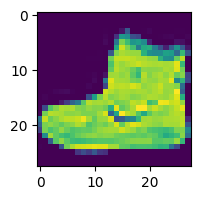

In [8]:
render_train_image(0)

### pre-process data

In [9]:
# pre-process train images
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
#train the model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

# create the model
model = Sequential()

# add the flatten layer
# since every image is 28x28, the input_shape is 28x28
model.add(Flatten(input_shape=[28, 28]))

# add the hidden layer
model.add(Dense(units=64, activation="relu"))

# since its a multi-class classification, use softmax as activation function on output layer
model.add(Dense(units=10, activation="softmax"))

# compile the model
model.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

In [ ]:
# build the model 
model.fit(train_images, train_labels, epochs=10)

In [12]:
#model Evaluation
predictions = model.predict(test_images)
len(predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


10000

label for 0th image = 9 with class = Ankle boot


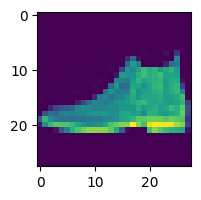

In [13]:
render_test_image(0)

In [14]:
predictions[0]

array([3.6313859e-06, 1.8360021e-08, 1.2782931e-05, 4.8459598e-05,
       3.9777792e-06, 5.8710959e-02, 1.5574868e-05, 5.1253252e-02,
       1.8712172e-03, 8.8808006e-01], dtype=float32)

In [ ]:
def predict_label(index):
    # show the image
    plt.figure(figsize=(2, 2))
    plt.imshow(test_images[index])

    # get the observed value
    print(f"observed class = {test_labels[index]} with class = {class_names[test_labels[index]]}")
    
    # get the prediction at the indexth location
    prediction = predictions[index]

    # find the max prediction
    max_probability = np.max(prediction)
    print(f"max probability = {max_probabi lity}")

    # find the index of max probability
    label_index = 0
    for probability in prediction:
        if probability == max_probability:
            print(f"predicted label index = {label_index} with class = {class_names[label_index]}")
            break
        label_index += 1

observed class = 6 with class = Shirt
max probability = 0.909459114074707
predicted label index = 6 with class = Shirt


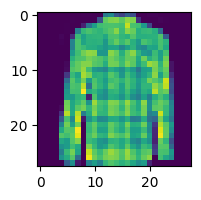

In [16]:
predict_label(2010)